# 6.3 DIN 候选感知排序

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

为什么同一位用户面对相机和跑鞋时应该激活不同历史？如何让用户表示依赖当前候选？

## Setup

本 Notebook 的默认真实数据是 **Amazon Reviews Electronics 5-core：DIN/DIEN 公开复现实验数据**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。

**主要资料：** [Zhou et al., 2018, DIN](https://arxiv.org/abs/1706.06978)

In [1]:
from pathlib import Path
import os, sys, json
import torch
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_ROOT = Path(os.environ.get("RECSYS_ARTIFACT_ROOT", PROJECT_ROOT)).expanduser().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("RECSYS_PROFILE", "full")
PROFILE = os.environ["RECSYS_PROFILE"]
CUDA_AVAILABLE = torch.cuda.is_available()
DATASET_KEY = "amazon-electronics"
# Setup 只声明执行边界。完整数据由章节 runner 在 Train & Inference 单元按需读取，
# 避免仅打开 Notebook 就解析数千万行文件。
REAL_DATASET = {
    "dataset": DATASET_KEY,
    "profile": PROFILE,
    "loading": "lazy: chapter runner owns loading and returns executed provenance",
    "randomly_fabricated_rows": 0,
}
print({"profile": PROFILE, "project_root": str(PROJECT_ROOT), "artifact_root": str(ARTIFACT_ROOT), "dataset_boundary": REAL_DATASET,
       "cuda_available": CUDA_AVAILABLE,
       "cuda_device": torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'project_root': '<ARTIFACT_ROOT>', 'artifact_root': '<ARTIFACT_ROOT>', 'dataset_boundary': {'dataset': 'amazon-electronics', 'profile': 'smoke', 'loading': 'lazy: chapter runner owns loading and returns executed provenance', 'randomly_fabricated_rows': 0}, 'cuda_available': False, 'cuda_device': None}


## 学习地图

1. 从原始论文理解系统约束；
2. 用可手算数字读懂公式和形状；
3. 检查数据、切分与标签；
4. 使用工业框架模型类训练；
5. 分开验证训练、推理和测试；
6. 用实际输出讨论失败边界。

**本节问题：** 为什么同一位用户面对相机和跑鞋时应该激活不同历史？如何让用户表示依赖当前候选？

**阅读约定：** 通用数学通过 3.0 基础课程链接回看；本页只详细推导论文引入或改造的数学。第一次阅读先追踪输入、输出和形状，再看梯度。

## Paper & Context

DIN（KDD 2018，阿里妈妈）从展示广告的真实瓶颈出发：Embedding&MLP 把用户历史压成与候选无关的固定长度向量。论文的贡献不止结构——mini-batch aware 正则化让上亿参数的稀疏网络用得起 ℓ2，Dice 让激活整流点随输入分布自适应；阿里线上 A/B 报告 CTR 最高 +10.0%。代价是每个候选都要重算历史注意力；论文自己尝试 LSTM 建模行为序列没有收益，把序列建模留给后续工作（即 DIEN）。

**来源：** [Zhou et al., 2018, DIN](https://arxiv.org/abs/1706.06978)

### 原文实验设计与关键结论

原文采用用户加权 AUC（GAUC）。Table 3（公开集各重复 5 次，初始化波动 <0.0002）：Amazon Electronics（192,403 用户、1,689,188 样本）DIN AUC 0.8818、Dice 版 0.8871，BaseModel 0.8624，RelaImpr 6.82%；MovieLens DIN+Dice 0.7348 对 BaseModel 0.7300。Table 5（阿里工业数据，约 20 亿训练样本）：DIN 0.6029，叠加 MBA 正则与 Dice 后 0.6083，RelaImpr 11.65%；论文注明该规模下 0.001 绝对 AUC 即值得上线。线上 A/B（2017-05~06）相对线上 BaseModel CTR 最高 +10.0%、RPM +3.8%。这些是阿里广告系统口径，教程在 KuaiRand 的数值另行报告，不能相减。

请区分三层证据：论文中的离线实验、本 Notebook 验证的代码链路、生产系统尚需验证的在线收益。三者不能互相替代。

## Reproduction Contract

**正式数据：** Amazon Reviews Electronics 5-core  
**资源 ID：** `amazon-electronics-5core`  
**切分：** paper-compatible chronological negative sampling  
**指标：** AUC, LogLoss  
**与论文比较边界：** Alibaba corpus is proprietary; public Amazon protocol is reproducible

`full` 只有在运行输出证明数据、切分、候选集、模型配置与指标均对齐时，才可能进入论文数值比较；它不是把教学适配器自动变成论文复现的开关。`smoke` 只做张量、损失和推理链路回归。

## Model Structure & Formula Walkthrough

![Figure 2 · DIN network architecture](/static/paper-figures/din.webp)

> **论文原图节选** · Figure 2 · DIN network architecture · PDF p.4。下图直接截取自原文，用于对照下方公式与代码。

### 关键模块

- **候选感知激活单元**：把当前候选物品 ad 与每条历史 $e_j$ 拼出 $[e_j, e_a, e_j-e_a, e_j\odot e_a]$，经小网络得到相关分。
- **加权兴趣池化**：对历史按相关分加权求和，$v_U=\sum_j a_j e_j$，所以同一用户面对不同候选会得到不同兴趣向量。
- **MLP + CTR 头**：候选、加权兴趣和其它特征拼接后过 MLP 与 Sigmoid，用二元交叉熵训练。

### 结构：候选先提问，历史再回答

记号：用户有 $L$ 条历史行为，第 $j$ 条的 embedding 是 $e_j\in\mathbb R^d$；当前候选（目标物品）的 embedding 是 $e_t\in\mathbb R^d$。一个 batch 的历史张量形状是 $[B,L,d]$：$B$ 个用户、每人 $L$ 条历史、每条 $d$ 维。

激活单元 $a(\cdot)$ 是一个小型全连接网络，输入是把四个向量拼成的 $4d$ 维向量 $[e_j,\ e_t,\ e_j-e_t,\ e_j\odot e_t]$，逐段含义：

- $e_j$：这条历史本身是什么；
- $e_t$：候选是什么；
- $e_j-e_t$：两者逐维差异，差的绝对值越小说明该维度上越接近；
- $e_j\odot e_t$：逐维乘积，两者同向的维度给出大的正值，是『共同激活』的显式信号。

手算例子：$d=2$，候选 $e_t=(1,0)$（想象成相机），历史 $e_1=(0.9,0.1)$（相关）与 $e_2=(0.1,0.9)$（不相关）。差异向量 $e_1-e_t=(-0.1,0.1)$、$e_2-e_t=(-0.9,0.9)$；逐维积 $e_1\odot e_t=(0.9,0)$、$e_2\odot e_t=(0.1,0)$。网络很容易从『差异小、乘积大』学出 $e_1$ 应得高权重。

输出相关分 $a_j=a(e_j,e_t)$ 后，必须区分论文与本教程实现的两种汇总：

$$\text{DIN 原论文：}\quad v_U(e_t)=\sum_{j=1}^{L}a_j e_j\quad\text{（不做 softmax）},$$
$$\text{Torch-RecHub 教学实现：}\quad \alpha_j=\frac{\exp(a_j)}{\sum_{j'}\exp(a_{j'})},\qquad v_U(e_t)=\sum_j\alpha_j e_j.$$

两者都让“哪个历史重要”依赖候选，但语义不同。原论文保留权重总量：面对 T 恤时，十条相关历史可以比一条相关历史产生更强激活；实现变体令权重和恒为 1，数值更稳定，却丢掉这部分强度。Notebook 的 NumPy 图演示的是 **softmax 实现变体**，不能倒写成原论文公式。张量链路都是 $[B,L,d]\to[B,L]\to[B,d]$。

### Dice：整流门槛随数据移动

ReLU 固定在 0 处截断，但 CTR 网络某一层的输入均值可能不是 0。Dice 先用当前 mini-batch 的均值 $\mu$ 和标准差 $\sigma$ 估计“高于常态”的概率，再在原斜率 1 与可学习斜率 $\alpha$ 之间切换：

$$p(s)=\operatorname{sigmoid}\!\left(\frac{s-\mu}{\sqrt{\sigma^2+\epsilon}}\right),\qquad \operatorname{Dice}(s)=p(s)s+[1-p(s)]\alpha s.$$

若 $s$ 明显高于本批均值，$p(s)\approx1$，输出接近 $s$；明显低于均值时输出接近 $\alpha s$。所以门槛跟随输入分布，而不是永远卡在 0。

### Mini-batch aware 正则：只惩罚本批真正查到的 embedding

完整 embedding 表可能有上亿行，每步遍历全表计算 $\ell_2$ 不现实。设第 $j$ 个特征域在当前 batch 激活的 ID 集合为 $S_j$，ID $s$ 的向量是 $w_j^{(s)}$，在全部训练样本中出现 $n_j^{(s)}$ 次；论文使用近似项

$$\Omega(W)=\lambda\sum_j\sum_{s\in S_j}\frac{\|w_j^{(s)}\|_2^2}{n_j^{(s)}}.$$

只读取本批出现的行，把计算量从“整张词表”降到“本批唯一 ID”；除以出现次数是为了避免高频 ID 因为被重复抽到而受到过强惩罚。最终 BCE 与正则相加。$v_U$ 再与候选、用户、上下文特征拼接进 MLP；每个候选都要重算权重，这既是 DIN 的表达力来源，也是在线成本。

### 公式到代码

`run_din` 严格在当前曝光之前构造历史；Torch-RecHub DIN 的 ActivationUnit 使用 `use_softmax=True`，因此源码映射明确标注它是归一化实现变体；Dice 与论文 MBA 正则是论文知识，是否启用必须以实际模型配置为准。

阅读源码时按“张量形状 → 前向计算 → score → loss → metric”五步追踪，不需要一次读完整个工程文件。

## Math by Hand

### 通用先修（先回看 3.0 基础课程）

- [曝光、点击与未知项](/notebooks/3_2_data_ml_basics#implicit-feedback)
- [张量形状与轴](/notebooks/3_3_linear_algebra#tensors-shapes)
- [逐元素乘积、点积与加权和](/notebooks/3_3_linear_algebra#elementwise-dot)
- [正则化与过拟合](/notebooks/3_7_optimization#regularization)

### 本论文新增数学（本节详细推导）

候选感知的 Local Activation Unit、原论文不归一化的兴趣汇总、Dice 激活与 mini-batch aware 正则化。

注意力分数 $a_j=g(e_j,e_t,e_j-e_t,e_j\odot e_t)$。原论文直接算 $v=\sum_j a_je_j$，不要求权重和为 1；下面代码为了对应 Torch-RecHub 的 `use_softmax=True` 实现，额外把原始分数归一化。候选『相机』为 $(1,0)$ 时，前两条历史获得较高比例；换成候选『跑鞋』$(0,1)$，比例立刻翻到后两条历史——这张图只验证“候选改变历史选择”，不声称两种汇总公式等价。

下面用 NumPy/Matplotlib 验证直觉。二维图只是教学投影，工业 embedding 虽有更多维，计算规则相同。

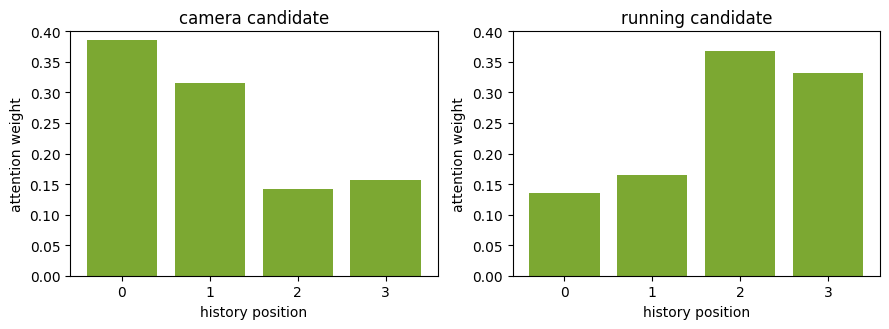

same history, different candidate -> different weights


In [2]:
import numpy as np, matplotlib.pyplot as plt
history=np.array([[1.,0.],[.8,.2],[0.,1.],[.1,.9]]); targets=[np.array([1.,0.]),np.array([0.,1.])]
fig,axes=plt.subplots(1,2,figsize=(9,3.4))
for ax,target,name in zip(axes,targets,['camera candidate','running candidate']):
    raw=history@target; weight=np.exp(raw)/np.exp(raw).sum(); ax.bar(range(4),weight,color='#7ca832')
    ax.set(ylim=(0,.4),title=name,xlabel='history position',ylabel='attention weight')
plt.tight_layout(); plt.show(); print('same history, different candidate -> different weights')

## Data

### 权威 full 协议（效果验收目标）

**正式数据：** Amazon Reviews Electronics 5-core  
**资源 ID：** `amazon-electronics-5core`  
**切分：** paper-compatible chronological negative sampling  
**指标：** AUC, LogLoss  
**与论文比较边界：** Alibaba corpus is proprietary; public Amazon protocol is reproducible

### smoke 教学适配器（默认 runner 实际读取）

KuaiRand-Pure 的真实 feed 曝光教学子集：候选是当前视频，历史只含该曝光之前的真实点击，标签直接读取 `is_click`。对 DIN，未点击曝光是当前样本的负标签，不会伪装成用户“主动不喜欢”。

下方运行结果打印的 provenance 才是本次执行事实；若资源、统计或切分与 full 协议不一致，就必须标记为不可比较。

**防泄漏清单：**按时间切分；item 映射只表达已知目录，不读取测试标签；低评分或未点击负反馈均来自数据中的已观察行；序列只看预测时刻以前；测试集只在最后评价。CPU 档使用真实数据的确定性子集，**不是统一 benchmark 成绩**。

## Model & Framework

实际使用 torch_rechub.models.ranking.DIN，调用 SequenceFeature、ActivationUnit 与 Dice MLP；full profile 配置序列截断、缓存和候选批处理。

smoke 档强调模型类、张量契约和指标链路真实可运行；full 档应替换原始数据、分布式配置、索引/服务和资源预算，而不是只增加 epoch。

In [3]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from importlib import import_module
from recsys_lab.runtime import print_progress, save_records

# 算法实现就在当前章节目录，不再通过公共模块隐藏。
chapter_train = import_module("chapter_code.6_3_din.train")
run_din = chapter_train.run_din

print("实际执行函数源码（包含数据、训练、推理和测试）：")
print(inspect.getsource(run_din))

实际执行函数源码（包含数据、训练、推理和测试）：
def run_din(epochs: int = 26, *, progress: ProgressCallback | None = None) -> dict:
    return _run_sequence_ranker("din", epochs, progress=progress)



## Train & Inference

下一格固定 seed、构造数据、实例化模型、训练并进入推理路径。生成式章节在 CUDA 上执行完整评测；CPU 环境只验证缩小后的基本张量与约束链路。

In [4]:
result = run_din(progress=print_progress)
REAL_DATASET = result['dataset']
assert REAL_DATASET['randomly_fabricated_rows'] == 0
print({'framework': result['framework'], 'dataset': result.get('dataset', {}),
       'device': result.get('device'), 'validation_mode': result.get('validation_mode')})
print('inference contract:', '对每个候选计算目标感知 attention，再拼接上下文打分；候选多时需缩短历史、缓存 embedding 或先预排。')
assert np.isfinite(result['loss_curve']).all()
print('loss:', round(result['loss_curve'][0],4), '→', round(result['loss_curve'][-1],4))

[data_prepare] 0/1 加载并构造 DIN 序列


[data_prepare] 1/1 rows=2600


[train] 0/26 starting


[train] 2/26 epoch 2/26 batch_loss=0.568127


[train] 4/26 epoch 4/26 batch_loss=0.450479


...

[baseline] 0/1 计算静态重合度基线


[baseline] 1/1 auc=0.501923


[evaluate] 0/1 计算 AUC 与 LogLoss


[evaluate] 1/1 auc=0.63819 logloss=0.518742


{'framework': 'torch_rechub.models.ranking.DIN', 'dataset': {'dataset': 'KuaiRand-Pure (Kuaishou, CIKM 2022)', 'source': 'https://zenodo.org/records/10439422/files/KuaiRand-Pure.tar.gz', 'source_sha256': 'c814bf6f3624c0cfae83c57de3df26b2ed206e5c57bab4c4dcbfabbabe20cbf0', 'license_file': '<ARTIFACT_ROOT>/data/kuairand-pure/LICENSE', 'slice_rule': 'top 256 users by standard-feed interaction count; ties by user_id; all standard and random-policy rows for those users retained', 'profile': 'smoke', 'local_resource': '<ARTIFACT_ROOT>/data/kuairand-pure/standard_interactions.csv', 'rows_used': 29602, 'users_used': 96, 'items_used': 2200, 'time_min_utc': '2022-04-09T04:29:16+00:00', 'time_max_utc': '2022-05-08T15:50:58+00:00', 'targets': 'observed is_click, long_view, is_like and other feed feedback', 'randomly_fabricated_rows': 0, 'rows': 2600, 'sequence_length': 20, 'label': 'observed KuaiRand is_click', 'negative_history': 'observed skipped impressions', 'time_ordered': True}, 'device': Non

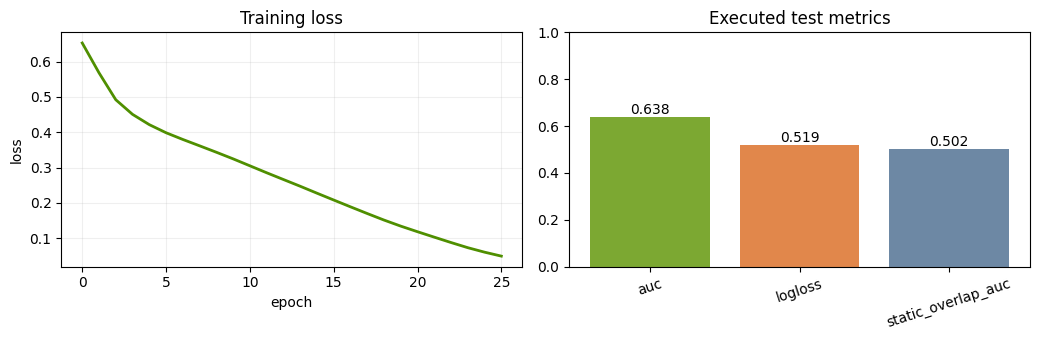

,value
auc,0.638190
logloss,0.518742
static_overlap_auc,0.501923


In [5]:
fig,axes=plt.subplots(1,2,figsize=(10.5,3.5))
axes[0].plot(result['loss_curve'],color='#4f8f00',lw=2); axes[0].set(title='Training loss',xlabel='epoch',ylabel='loss'); axes[0].grid(alpha=.2)
metrics={'auc': result['auc'], 'logloss': result['logloss'], 'static_overlap_auc': result['static_overlap_auc']}
axes[1].bar(range(len(metrics)),list(metrics.values()),color=['#7ca832','#e1874b','#6d88a4'][:len(metrics)])
axes[1].set_xticks(range(len(metrics)),list(metrics),rotation=18); axes[1].set(title='Executed test metrics',ylim=(0,max(1.0,max(metrics.values())*1.15)))
for index,value in enumerate(metrics.values()): axes[1].text(index,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show(); display(pd.Series(metrics,name='value').to_frame())

In [6]:
# 论文数字只能在数据、切分、候选和指标全部同口径时相减。
paper_protocol = json.loads('{"dataset": "Amazon Reviews Electronics 5-core", "resource": "amazon-electronics-5core", "split": "paper-compatible chronological negative sampling", "metrics": ["AUC", "LogLoss"], "paper_comparison": "Alibaba corpus is proprietary; public Amazon protocol is reproducible"}')
paper_targets = paper_protocol.get('paper_targets', {})
metric_key = {'HitRate@10':'paper_protocol_hr@10', 'NDCG@10':'paper_protocol_ndcg@10',
              'AUC':'auc', 'LogLoss':'logloss'}
dataset_name = result.get('dataset', {}).get('dataset', '')
dataset_aligned = paper_protocol.get('dataset', '').split(',')[0].casefold() in dataset_name.casefold()
comparison_eligible = PROFILE == 'full' and dataset_aligned
rows=[]
for paper_metric,target in paper_targets.items():
    result_key=metric_key.get(paper_metric)
    value=result.get(result_key) if result_key else None
    rows.append({'metric':paper_metric,'tutorial':value,'paper':target,
                 'absolute_gap':None if value is None or not comparison_eligible else float(value)-float(target),
                 'comparable':comparison_eligible and value is not None})
if rows:
    display(pd.DataFrame(rows))
    if not comparison_eligible:
        print('NOT COMPARABLE：当前运行的数据/协议与论文不完全一致，不计算复现差值。')
else:
    print('论文没有可公开、可同口径复现的绝对目标；本节只报告结构与公开协议验证。')

论文没有可公开、可同口径复现的绝对目标；本节只报告结构与公开协议验证。


## Test & Results Discussion

In [7]:
display(Markdown(f'''### 本次已执行结果

- 主指标 auc = **{result['auc']:.4f}**。
- 辅助指标 logloss = **{result['logloss']:.4f}**。
- 对照指标 static_overlap_auc = **{result['static_overlap_auc']:.4f}**。
- 训练损失从 **{result['loss_curve'][0]:.4f}** 降到 **{result['loss_curve'][-1]:.4f}**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 真实小数据上静态基线可能更高；这正说明必须设置诚实 baseline，模型复杂度本身不是收益。

### 工业边界

对每个候选计算目标感知 attention，再拼接上下文打分；候选多时需缩短历史、缓存 embedding 或先预排。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。
'''))

### 本次已执行结果

- 主指标 auc = **0.6382**。
- 辅助指标 logloss = **0.5187**。
- 对照指标 static_overlap_auc = **0.5019**。
- 训练损失从 **0.6525** 降到 **0.0491**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 真实小数据上静态基线可能更高；这正说明必须设置诚实 baseline，模型复杂度本身不是收益。

### 工业边界

对每个候选计算目标感知 attention，再拼接上下文打分；候选多时需缩短历史、缓存 embedding 或先预排。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。


In [8]:
record={
    'algorithm': 'DIN 候选感知排序',
    'primary_metric': 'auc', 'primary_value': float(result['auc']),
    'secondary_metric': 'logloss', 'secondary_value': float(result['logloss']),
    'baseline_metric': 'static_overlap_auc',
    'baseline_value': float(result['static_overlap_auc']) if True else None,
    'framework': result['framework'], 'source_notebook': '6_3_din',
    'validation_mode': result.get('validation_mode', 'standard'),
    'dataset': result['dataset']['dataset'],
    'randomly_fabricated_rows': int(result['dataset']['randomly_fabricated_rows'])
}
path=save_records('chapter_6','6_3_din',[record]); print('saved:',path.relative_to(ARTIFACT_ROOT))

saved: results/chapter_6/6_3_din.json


## Checks

自动断言用于防止数据、训练和指标链路静默失效，不是效果证明。

In [9]:
assert result['loss_curve'][-1] < result['loss_curve'][0]
assert 0 <= float(result['auc']) <= 1
assert np.isfinite(float(result['logloss']))
print('PASS：数据、训练、推理、测试和结果产物均已验证。')

PASS：数据、训练、推理、测试和结果产物均已验证。


## Next Steps

1. 换成对应公开数据的完整时间切分；2. 增加强 baseline 与消融；3. 记录效果、延迟和成本；4. 映射到 TorchEasyRec/官方 full profile；5. 只在相同候选与数据口径下比较。